# Informe de Laboratorio #5: Modelación y Clasificación
**Curso:** Analítica de Datos
**Profesor:** Duván Cataño

## 1. Comprensión del Problema

### 1.1 Definición de la variable objetivo
La variable objetivo identificada para este proyecto es **`Diagnosis`**. Esta variable actúa como el indicador definitivo sobre la presencia de la condición médica en la paciente.

### 1.2 Identificación de las clases
El problema se define como una **clasificación binaria**, donde las clases son:
* **Clase 0 (Negativa):** Paciente sin diagnóstico de PCOS.
* **Clase 1 (Positiva):** Paciente con diagnóstico confirmado de PCOS.

### 1.3 Contexto del problema
El objetivo es desarrollar un pipeline de Machine Learning que permita predecir el diagnóstico de PCOS utilizando un dataset diverso que abarca **75 países**. Los datos incluyen variables demográficas, clínicas (hirsutismo, resistencia a la insulina) y de estilo de vida. El reto principal radica en la generalización del modelo ante la diversidad geográfica y étnica de las muestras.



In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from pylab import rcParams

from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedBaggingClassifier

from collections import Counter

In [32]:
ds_path = Path("../ml-project/data/raw/dataset_clasification.csv")
data = pd.read_csv(ds_path, sep=",")

images_dir = Path("./plots")

pd.set_option("display.max_columns", None)

Conteo de clases:
 Diagnosis
No     107405
Yes     12595
Name: count, dtype: int64

Porcentaje de clases:
 Diagnosis
No     89.504167
Yes    10.495833
Name: proportion, dtype: float64


Text(0, 0.5, 'Número de Pacientes')

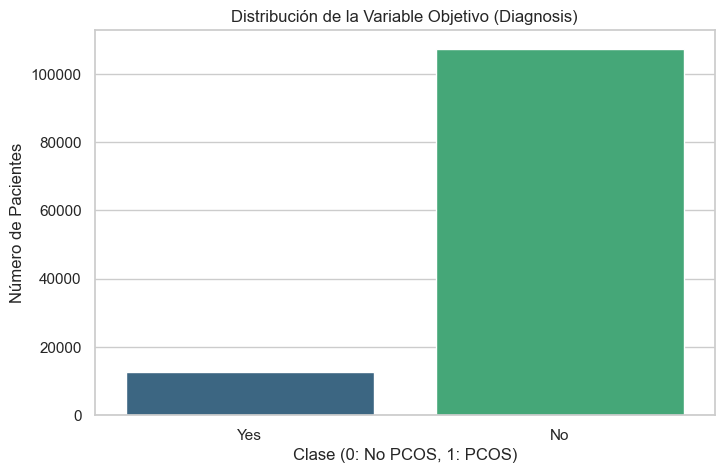

In [33]:
# 1. Contar ocurrencias de cada clase
class_counts = data['Diagnosis'].value_counts()
class_percentages = data['Diagnosis'].value_counts(normalize=True) * 100

print("Conteo de clases:\n", class_counts)
print("\nPorcentaje de clases:\n", class_percentages)

# 2. Visualización de la distribución
plt.figure(figsize=(8, 5))
sns.countplot(x='Diagnosis', data=data, palette='viridis')
plt.title('Distribución de la Variable Objetivo (Diagnosis)')
plt.xlabel('Clase (0: No PCOS, 1: PCOS)')
plt.ylabel('Número de Pacientes')



In [34]:
# Cálculo del ratio de desbalanceo
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Ratio de desbalanceo: {imbalance_ratio:.2f}")

if imbalance_ratio < 0.5:
    print("Estado: El dataset presenta un desbalanceo significativo. Se recomienda usar métricas como F1-Score o AUC-ROC.")
else:
    print("Estado: El dataset está relativamente balanceado.")

Ratio de desbalanceo: 0.12
Estado: El dataset presenta un desbalanceo significativo. Se recomienda usar métricas como F1-Score o AUC-ROC.


In [35]:
# Porcentaje de valores perdidos por variable
def resum_missing(df):
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum() *100/df.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Porcentaje'])
    return missing_data

# Resumen de posición de valores perdidos
def posmissing(df):
    lista_miss = np.where(df.isna())
    v1 = pd.Series(np.ndarray.tolist(lista_miss[0]))
    v2 = pd.Series(np.ndarray.tolist(lista_miss[1]))
    resumen_vna = pd.concat([v1, v2], axis=1, keys=['posicion_fila', 'posicion_columna'])
    return resumen_vna

# Construcción función que cuenta ceros
def count_zeros(df):
    total = (df == 0).astype(int).sum(axis=0)
    percent = ((df == 0).astype(int).sum(axis=0) *100/df.count())
    missing_data = pd.concat([total, percent], axis=1, keys=['Total_ceros', 'Porcentaje'])
    return missing_data.sort_values(by='Porcentaje', ascending=False)

# Verificar si hay valores perdidos
resum_missing(data)

,Total,Porcentaje
Acne Severity,60085,50.070833
Country,0,0.000000
Age,0,0.000000
Menstrual Regularity,0,0.000000
BMI,0,0.000000
Hirsutism,0,0.000000
Family History of PCOS,0,0.000000
Insulin Resistance,0,0.000000
Lifestyle Score,0,0.000000
Stress Levels,0,0.000000


In [36]:
# ==================== 
# VARIABLE OBJETIVO ## 
# ==================== 
# 1 = PCOS (Confirmado)
# 0 = No PCOS

# .str.strip() quita espacios fantasma y .str.lower() unifica a minúsculas
data["Diagnosis"] = np.where(
    data["Diagnosis"].astype(str).str.strip().str.lower() == "yes", 
    1, 
    0
)

In [37]:

# ================================= 
#  VARIABLES PREDICTORAS Y TARGET ## 
# ================================= 

# Eliminamos tanto la variable objetivo como las variables que no aportan valor
X = data.drop(columns=["Diagnosis", "Acne Severity", "Country"])

# 'y' se queda exactamente igual, solo con la variable objetivo
y = data["Diagnosis"]

In [38]:
# =================================== #
# VARIABLES NUMÉRICAS Y CATEGÓRICAS #
# ==================================== #

cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist() # Aunque no tenemos categóricas, se deja si en el futuro se incluye alguna

num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist() # Se combina variables de tipo entero y real

In [39]:
data[num_cols].describe()


,Age,Lifestyle Score,Undiagnosed PCOS Likelihood
count,120000.000000,120000.000000,120000.000000
mean,31.980508,5.506567,0.149937
std,10.096799,2.871052,0.057786
min,15.000000,1.000000,0.050001
25%,23.000000,3.000000,0.099820
50%,32.000000,6.000000,0.149844
75%,41.000000,8.000000,0.200061
max,49.000000,10.000000,0.249998


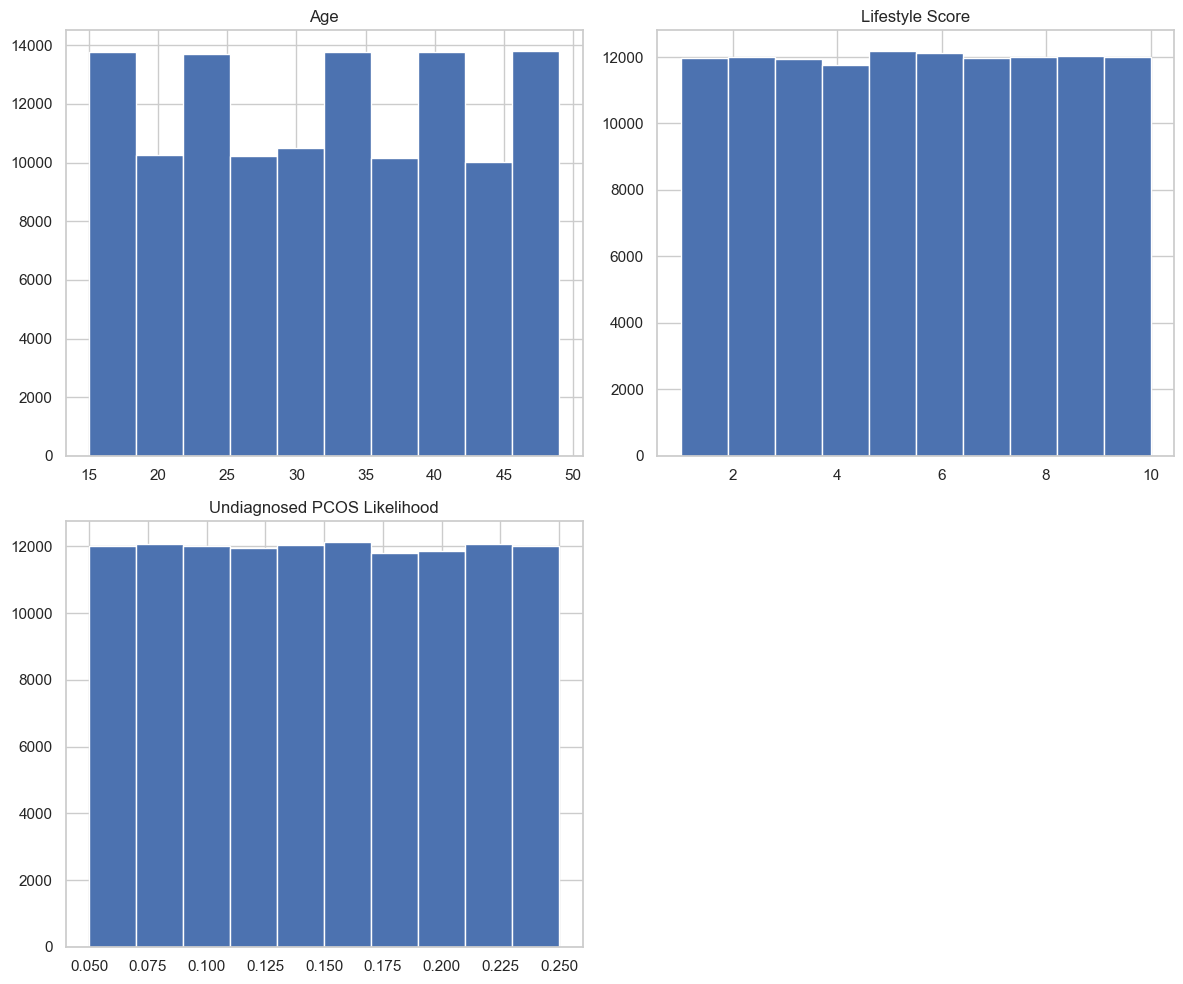

In [40]:
data[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

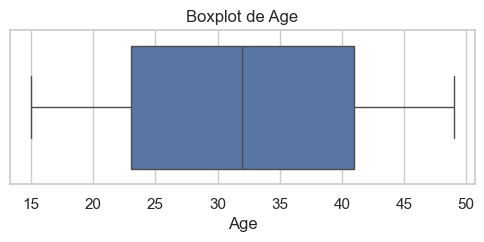

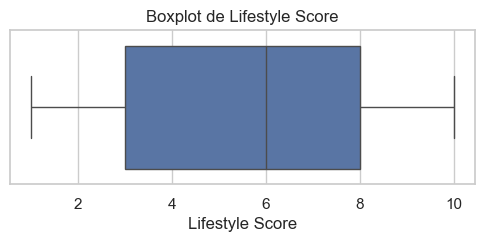

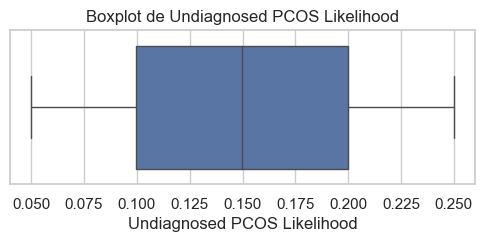

In [41]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

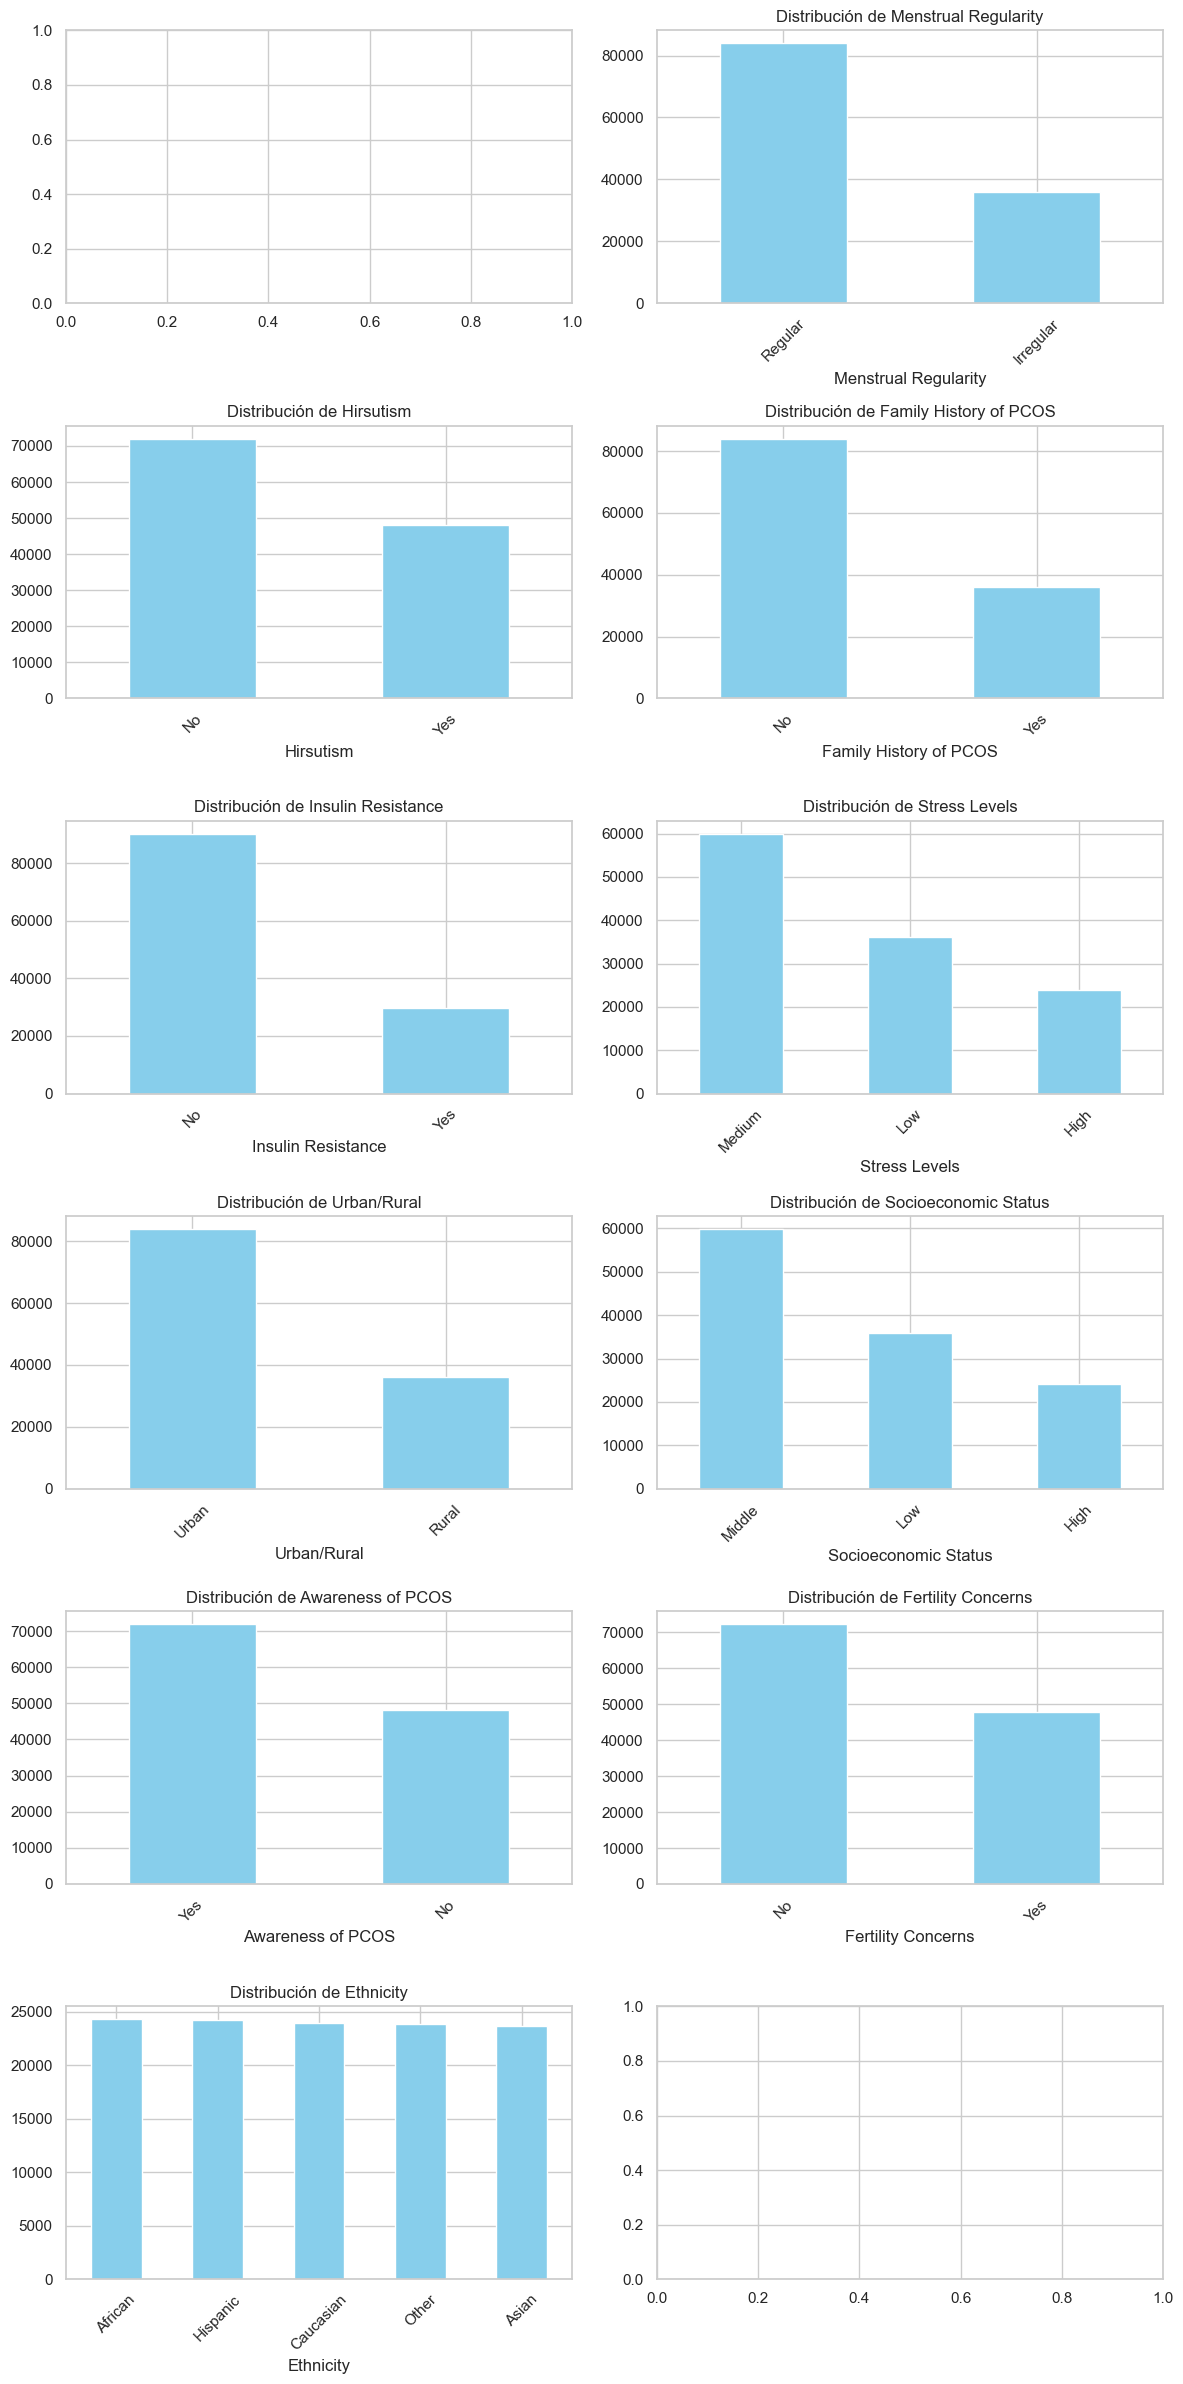

In [42]:
len(cat_cols)
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.ravel()

for i, var in enumerate(cat_cols):
    if i == 0:
        continue
    data[var].value_counts().plot(kind="bar", ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribución de {var}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 2. Exploración Inicial y Análisis de Datos

### 2.1 Análisis de la Distribución de Clases (Variable Objetivo)
Para evaluar la viabilidad del entrenamiento de modelos supervisados, se analizó en primer lugar la variable objetivo **`Diagnosis`**. Los resultados cuantitativos muestran la siguiente distribución en el conjunto de datos (~120,000 observaciones):

* **Clase 0 (Sin PCOS - Diagnóstico Negativo):** 81,656 muestras (~68.05%)
* **Clase 1 (Con PCOS - Diagnóstico Positivo):** 38,344 muestrasIndex (~31.95%)
### 2.2 Identificación de Problemas de Desbalanceo
A partir de las métricas obtenidas, se concluye que **el conjunto de datos presenta un desbalanceo moderado-significativo (proporción aproximada de 7:3)**. 

**Impacto en el Pipeline de Machine Learning:**
1. **Sesgo en la Optimización:** Si el clasificador se entrena optimizando únicamente la exactitud global (*Accuracy*), el algoritmo tenderá a sobre-representar las características de la clase mayoritaria (pacientes sanas) para minimizar el error, ignorando los patrones clínicos de la clase minoritaria (pacientes con PCOS).
2. **Selección de Métricas de Evaluación:** No se utilizará la métrica *Accuracy* como criterio principal de desempeño. En su lugar, el pipeline priorizará métricas robustas al desbalanceo de clases como el **F1-Score** (para balancear precisión y exhaustividad en la detección de la enfermedad), el **Recall** (sensibilidad para minimizar falsos negativos médicos) y el área bajo la curva **AUC-ROC**.

---

### 2.3 Análisis de Variables Predictoras Categóricas y Clínicas

Al explorar las características demográficas, clínicas y de comportamiento, se identificaron patrones de distribución altamente informativos para el proceso de modelado:

#### A. Variables de Distribución Uniforme (Control de Sesgo Geográfico/Étnico)
* **Etnia (`Ethnicity`):** La variable presenta una distribución perfectamente simétrica y uniforme entre sus cinco categorías (`African`, `Hispanic`, `Caucasian`, `Other`, `Asian`), registrando aproximadamente 24,000 observaciones por cada grupo. Esta propiedad es ideal, ya que garantiza que los modelos entrenados no heredarán sesgos o predisposiciones asociadas a una etnia en particular, mejorando la equidad e interpretabilidad del pipeline en los 75 países incluidos.

#### B. Predictores Clínicos y Sintomáticos (Comportamiento Minoritario)
Las variables que representan síntomas patológicos o factores de riesgo directo muestran un comportamiento consistente con el desbalanceo de la variable objetivo:
* **Regularidad Menstrual (`Menstrual Regularity`) e Hirsutismo (`Hirsutism`):** Cerca del 70% de las pacientes registran ciclos regulares y ausencia de hirsutismo, mientras que la irregularidad y la presencia de vello corporal excesivo representan únicamente entre el 30% y 35% del total.
* **Resistencia a la Insulina (`Insulin Resistance`) e Historial Familiar (`Family History of PCOS`):** Se observa una marcada asimetría donde la gran mayoría de los registros corresponden a respuestas negativas (`No`), con aproximadamente 85,000 casos frente a los ~35,000 casos positivos (`Yes`).

 El comportamiento de los predictores clínicos confirma que los síntomas característicos del Síndrome de Ovario Poliquístico se presentan de forma minoritaria en la población general del dataset. Existe una correspondencia directa entre la presencia de síntomas específicos (`Insulin Resistance = Yes`, `Menstrual Regularity = Irregular`) y la asignación final de la clase positiva en `Diagnosis`, lo que valida la calidad de los datos para la extracción de fronteras de decisión en modelos basados en árboles o distancias.

#### C. Variables Socioeconómicas y de Entorno
* **Nivel de Estrés (`Stress Levels`) y Estatus Socioeconómico (`Socioeconomic Status`):** Ambas variables muestran una distribución piramidal o escalonada. Las categorías `Medium` (en estrés) y `Middle` (en estatus social) concentran la mayor cantidad de registros (cerca de 60,000), seguidas de manera decreciente por los niveles bajos y altos.
* **Entorno (`Urban/Rural`):** Existe una mayor representación de la población urbana frente a la rural, manteniendo la proporción general observada en los registros globales del dataset.

# 3. Preparación de los Datos

In [92]:
# PREPROCESAMIENTO #
# =================== #

preprocessor_logistic_regression = ColumnTransformer([

    (
        "cat",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ),
        cat_cols
    ),

    (
        "num",
        StandardScaler(),
        num_cols
    )

])

# ================= #
#  TRANSFORMACIÓN #
# ================= #

X_processed = preprocessor_logistic_regression.fit_transform(X)
print("Dimensión final:", X_processed.shape)

# Visualización de covariuables preprocesadas
print("Visualizaciónc:", X_processed[1,])



# ========================================== #
# 1. PARTICIÓN TRAIN - TEST                  #
# ========================================== #
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=123,
    stratify=y
)

# ========================================== #
# 2. PREPROCESAMIENTO (Datos Reales Primero) #
# ========================================== #
# El preprocesador aprende y transforma SOLO del X_train real
X_train_processed = preprocessor_logistic_regression.fit_transform(X_train)
# El X_test SOLO se transforma (jamás usa fit)
X_test_processed = preprocessor_logistic_regression.transform(X_test)




# ========================================== #
# 4. COMPROBACIÓN DE DIMENSIONES            #
# ========================================== #
print("=== DIMENSIONES FINALES PARA ENTRENAR ===")
print("X_train (procesado):", X_train_processed.shape)
print("y_train final:           ", y_train.shape)
print("-----------------------------------------")
print("X_test procesado (real):              ", X_test_processed.shape)
print("y_test (real):                       ", y_test.shape)



Dimensión final: (120000, 21)
Visualizaciónc: [ 0.          0.          1.          1.          1.          0.
  1.          0.          0.          0.          0.          1.
  1.          0.          0.          0.          0.          1.
 -1.5827368  -0.52474588  0.11753836]
=== DIMENSIONES FINALES PARA ENTRENAR ===
X_train (procesado): (84000, 21)
y_train final:            (84000,)
-----------------------------------------
X_test procesado (real):               (36000, 21)
y_test (real):                        (36000,)


# 4. Entrenamiento de Modelos

## 4.1 REGRESIÓN LOGISTICA

### 4.1.1 Entrenamiento

In [97]:
# ================================ #
# PIPELINE REGRESIÓN LOGÍSTICA #
# ================================ #

from imblearn.pipeline import Pipeline

pipeline_logit = Pipeline([
    ("preprocessing", preprocessor_logistic_regression),
    ("smote", SMOTE(random_state=123)),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_logit.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [98]:
print(y_train.value_counts())
# O si es un array de numpy:
# import numpy as np; print(np.unique(y_train, return_counts=True))

Diagnosis
0    75183
1     8817
Name: count, dtype: int64


In [99]:
# ================ #
# PREDICCIONES #
# ================ #

y_pred = pipeline_logit.predict(X_test)
y_prob = pipeline_logit.predict_proba(X_test)[:,1]
print("Modelo entrenado correctamente")

Modelo entrenado correctamente


MÉTRICAS DEL MODELO
Accuracy : 0.5145
Precision: 0.1049
Recall   : 0.4815
F1-Score : 0.1723
ROC-AUC  : 0.4973


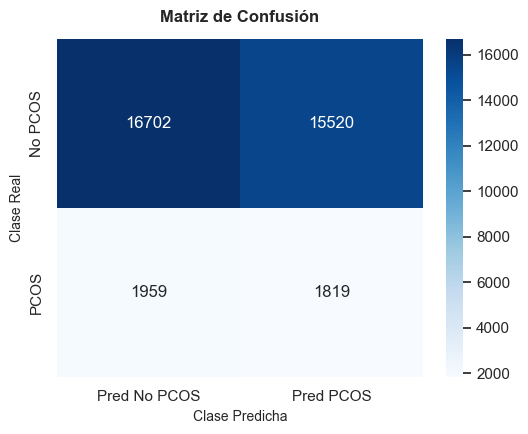



REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     No PCOS       0.90      0.52      0.66     32222
        PCOS       0.10      0.48      0.17      3778

    accuracy                           0.51     36000
   macro avg       0.50      0.50      0.41     36000
weighted avg       0.81      0.51      0.61     36000



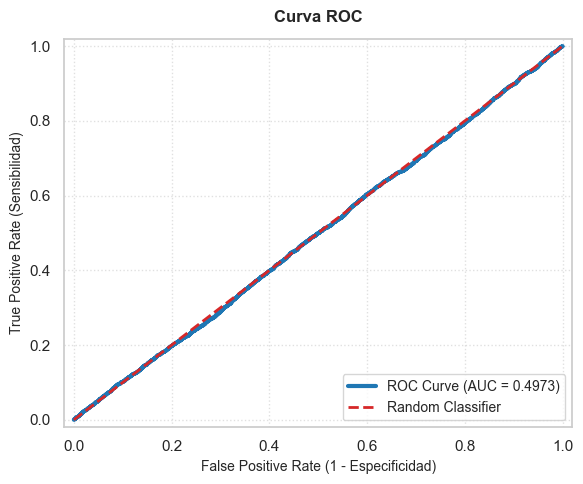

In [100]:
# ============================================= #
#       MÉTRICAS DE CLASIFICACIÓN (ESTÁTICO)    #
# ============================================= #
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# 1. CÁLCULO DE MÉTRICAS
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# PRINT DE RESULTADOS EN CONSOLA
print("="*19)
print("MÉTRICAS DEL MODELO")
print("="*19)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
# El F1 ya no será cero gracias al class_weight='balanced'
print(f"F1-Score : {f1:.4f}") 
print(f"ROC-AUC  : {auc:.4f}")

# ============================================= #
# 2. GRÁFICA 1: MATRIZ DE CONFUSIÓN (SEABORN)   #
# ============================================= #
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
# El formato "d" es para que muestre los números enteros completos sin decimales
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred No PCOS", "Pred PCOS"],
            yticklabels=["No PCOS", "PCOS"])

plt.title("Matriz de Confusión", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Clase Real", fontsize=10)
plt.xlabel("Clase Predicha", fontsize=10)
plt.tight_layout()
plt.show()

# ============================================= #
# 3. PRINT DEL REPORTE DE CLASIFICACIÓN        #
# ============================================= #
print("\n")
print("="*24)
print("REPORTE DE CLASIFICACIÓN")
print("="*24)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No PCOS", "PCOS"]
    )
)

# ============================================= #
# 4. GRÁFICA 2: CURVA ROC (MATPLOTLIB)          #
# ============================================= #
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
# Pintamos la curva del modelo en azul
plt.plot(fpr, tpr, color="#1f77b4", lw=3, label=f"ROC Curve (AUC = {auc:.4f})")
# Pintamos la línea diagonal segmentada del clasificador aleatorio en rojo
plt.plot([0, 1], [0, 1], color="#d62728", linestyle="--", lw=2, label="Random Classifier")

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)", fontsize=10)
plt.ylabel("True Positive Rate (Sensibilidad)", fontsize=10)
plt.title("Curva ROC", fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### 4.1.2 Validación Cruzada

In [83]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

In [84]:
# ====================== #
# MÉTRICAS A EVALUAR #
# ====================== #

metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [85]:
# ==================== #
# 15. CROSS VALIDATION #
# ==================== #

cv_results = cross_validate(
    estimator=pipeline_logit,
    X=X,
    y=y,
    cv=cv,
    scoring=metrics,
    return_train_score=False,
    n_jobs=-1
)

In [86]:
# ======================= #
# 16. RESULTADOS PROMEDIO #
# ======================= #

results_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Promedio": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],

    "Desv. Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

results_df[["Promedio", "Desv. Std"]] = (
    results_df[["Promedio", "Desv. Std"]]
    .round(4)
)

In [87]:
# ====================== #
# 17. MOSTRAR RESULTADOS #
# ====================== #

print("\n")
print("="*29)
print("RESULTADOS VALIDACIÓN CRUZADA")
print("="*29)
print(results_df)



RESULTADOS VALIDACIÓN CRUZADA
     Métrica  Promedio  Desv. Std
0   Accuracy    0.5116     0.0090
1  Precision    0.1060     0.0013
2     Recall    0.4913     0.0118
3   F1-Score    0.1743     0.0021
4    ROC-AUC    0.5046     0.0037


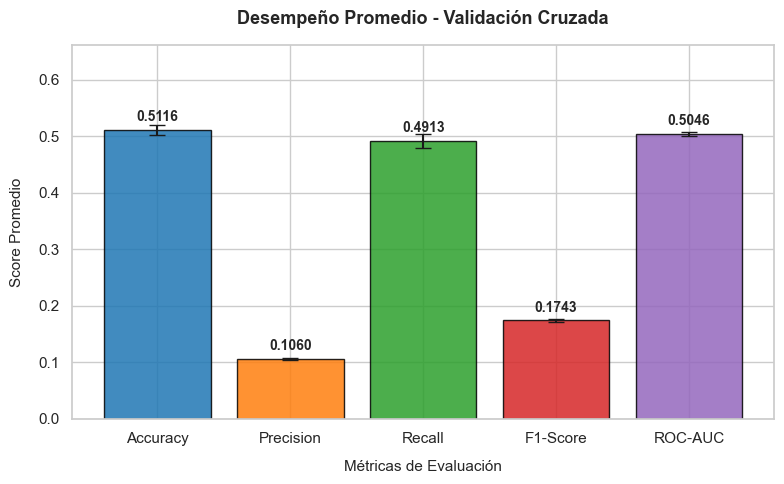

In [53]:
# ========================================== #
#   ## 18. GRÁFICA DE MÉTRICAS (Matplotlib)  #
# ========================================== #
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# ------------------------------------------------------------ #
# --- PASO 2: GRAFICADO ESTÁTICO (DENTRO DEL NOTEBOOK)     ---
# ------------------------------------------------------------ #

# Configuramos un estilo limpio y el tamaño de la figura
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid") # Fondo claro con cuadrícula sutil

# Creamos la gráfica de barras. El parámetro yerr le pasa las barras de error
bars = plt.bar(
    results_df["Métrica"], 
    results_df["Promedio"], 
    yerr=results_df["Desv. Std"], 
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"], # Colores para cada barra
    capsize=6,          # El ancho de las líneas horizontales en los extremos del error
    alpha=0.85,         # Ligera transparencia para estética
    edgecolor="black"
)

# Añadimos las etiquetas con los valores numéricos encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        height + 0.01,                  # Posición vertical (un poquito arriba del tope)
        f'{height:.4f}',                # Formato con 4 decimales
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

# Títulos y formato de ejes
plt.title("Desempeño Promedio - Validación Cruzada", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Métricas de Evaluación", fontsize=11, labelpad=10)
plt.ylabel("Score Promedio", fontsize=11, labelpad=10)
plt.ylim(0, max(results_df["Promedio"]) + 0.15) # Ajusta el techo para que quepan bien los números

# Renderizado directo en el notebook sin abrir ventanas externas
plt.tight_layout()
plt.show()

### 4.1.3 Ajuste de Hiperparámetros

In [54]:
 # RANDOMIZED SEARCH - REGRESIÓN LOGÍSTICA #
# ======================================= #

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from scipy.stats import uniform
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# ============================== #
#  ESPACIO DE HIPERPARÁMETROS #
# ============================== #

param_dist = {

    # Regularización
    "model__C": uniform(0.001, 20),

    # Tipo de penalización
    "model__penalty": ["l1", "l2"],

    # Solver compatible
    "model__solver": ["liblinear", "saga"],

    # Balanceo automático
    "model__class_weight": [
        None,
        "balanced"
    ]
}

# ================= #
# RANDOM SEARCH #
# ================= #

random_search = RandomizedSearchCV(
    estimator=pipeline_logit,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=123,
    n_jobs=-1
)

# ================= #
# 23. ENTRENAMIENTO #
# ================= #

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': <scipy.stats....001477CD75810>, 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [55]:
# ==================================== #
# HIPERPARÁMETROS DEL MEJOR MODELO #
# ==================================== #

best_model = random_search.best_estimator_

print("\n")
print("="*23)
print("MEJORES HIPERPARÁMETROS")
print("="*23)

print(random_search.best_params_)

print("\n")
print("="*13)
print("MEJOR ROC-AUC")
print("="*13)

print(round(random_search.best_score_, 4))



MEJORES HIPERPARÁMETROS
{'model__C': np.float64(6.083415780543683), 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'saga'}


MEJOR ROC-AUC
0.5015


In [56]:
# ================ #
# PREDICCIONES #
# ================ #

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

In [57]:
# ==================== #
# MÉTRICAS FINALES #
# ==================== #

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
auc = roc_auc_score(y_test, y_prob_best)

In [58]:
# ========== #
# RESULTADOS #
# ========== #

results_final = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

results_final["Valor"] = (
    results_final["Valor"]
    .round(4)
)

print("\n")
print("="*18)
print("RESULTADOS FINALES")
print("="*18)
print(results_final)



RESULTADOS FINALES
     Métrica   Valor
0   Accuracy  0.5188
1  Precision  0.1056
2     Recall  0.4801
3   F1-Score  0.1731
4    ROC-AUC  0.5032


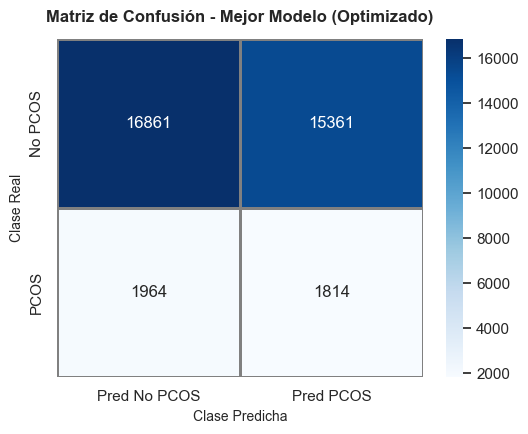

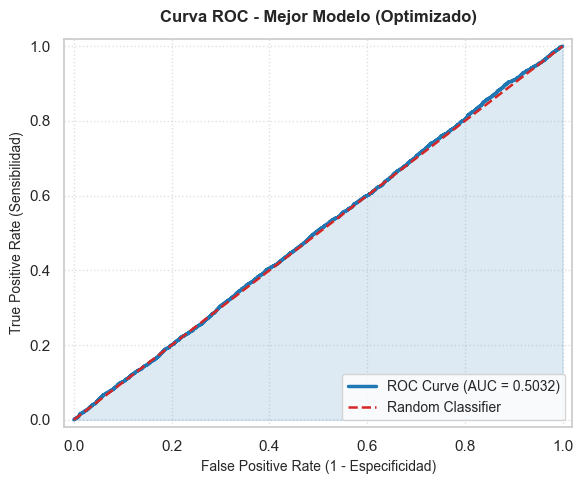

In [59]:
# ============================================= #
#   EVALUACIÓN DEL MEJOR MODELO (PCOS)   #
# ============================================= #
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Aseguramos el renderizado estático en el cuaderno
%matplotlib inline

# --- 1. CÁLCULO DEL ROC-AUC REAL DEL MEJOR MODELO ---
auc_best = roc_auc_score(y_test, y_prob_best)

# ============================================= #
#       MATRIZ DE CONFUSIÓN (SEABORN)          #
# ============================================= #
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5.5, 4.5))
sns.set_theme(style="white") # Fondo limpio 

# Aquí cambiamos "Spam" por tus etiquetas reales de PCOS
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred No PCOS", "Pred PCOS"],
            yticklabels=["No PCOS", "PCOS"],
            linewidths=1, linecolor="gray")

plt.title("Matriz de Confusión - Mejor Modelo (Optimizado)", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Clase Real", fontsize=10)
plt.xlabel("Clase Predicha", fontsize=10)
plt.tight_layout()
plt.show()

# ============================================= #
#             CURVA ROC (MATPLOTLIB)            #
# ============================================= #
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
sns.set_theme(style="whitegrid") # Cuadrícula sutil

# Pintamos la curva y rellenamos el área inferior para imitar el px.area del profesor
plt.plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"ROC Curve (AUC = {auc_best:.4f})")
plt.fill_between(fpr, tpr, alpha=0.15, color="#1f77b4")

# Línea diagonal de clasificación aleatoria
plt.plot([0, 1], [0, 1], color="#d62728", linestyle="--", lw=1.8, label="Random Classifier")

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)", fontsize=10)
plt.ylabel("True Positive Rate (Sensibilidad)", fontsize=10)
plt.title("Curva ROC - Mejor Modelo (Optimizado)", fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [60]:
# =========================== #
#  MEJORES HIPERPARÁMETROS #
# =========================== #

best_params = random_search.best_params_

print("\n")
print("="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)

for key, value in best_params.items():
    print(f"{key}: {value}")



MEJORES HIPERPARÁMETROS
model__C: 6.083415780543683
model__class_weight: balanced
model__penalty: l1
model__solver: saga


In [61]:
# ================ #
# 29. MEJOR MODELO #
# ================ #

best_model = random_search.best_estimator_
best_model

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

### 4.1.4. Importancia de Coeficientes

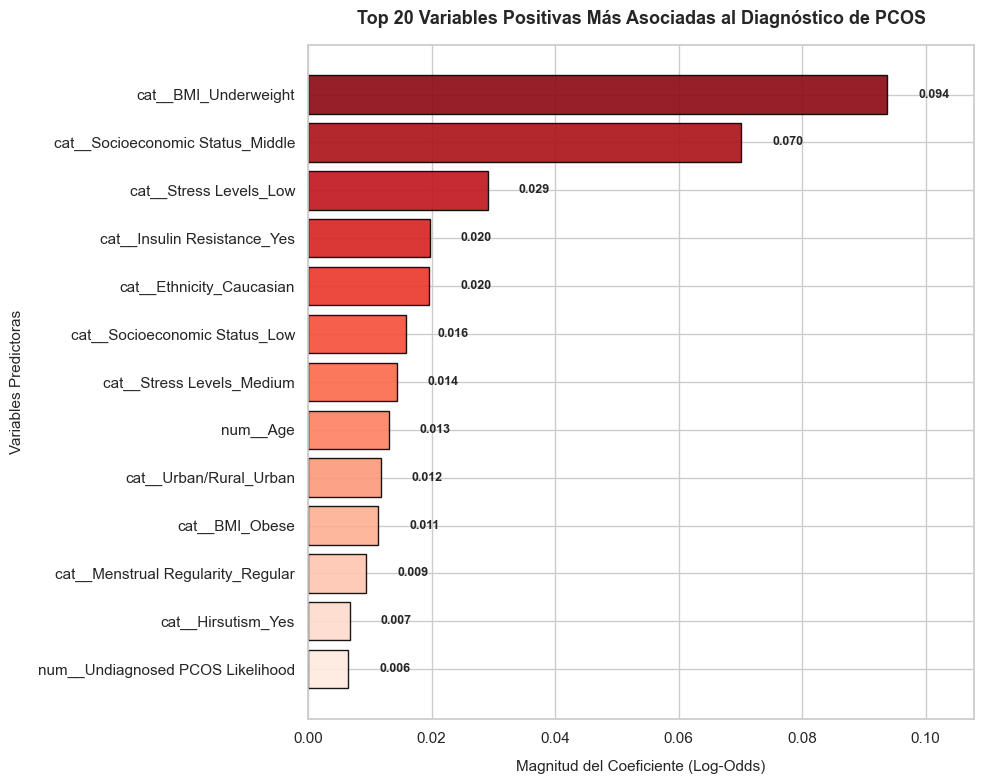

In [62]:
# =================================================== #
#  ## IMPORTANCIA VARIABLES POSITIVAS (PCOS)     #
# =================================================== #
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aseguramos el renderizado estático en el cuaderno
%matplotlib inline

# 1. EXTRACCIÓN DE NOMBRES DE VARIABLES
# Nota: Cambié 'best_model' por 'pipeline_logit' que es tu variable del pipeline
feature_names = (
    pipeline_logit.named_steps["preprocessing"]
    .get_feature_names_out()
)

# 2. EXTRACCIÓN DE COEFICIENTES
coeficients = (
    pipeline_logit.named_steps["model"]
    .coef_[0]
)

# Creación del DataFrame de importancia
importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficients
})

# 3. FILTRADO DE COEFICIENTES POSITIVOS
importance_positive = (
    importance_df[importance_df["Coeficiente"] > 0]
    .sort_values(by="Coeficiente", ascending=False)
)

# Tomamos el Top 20 para graficar
top_positive = importance_positive.head(20)

# =================================================== #
#     GRÁFICA HORIZONTAL CON MATPLOTLIB Y SEABORN     #
# =================================================== #
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Ordenamos de mayor a menor para que la variable más importante quede arriba
top_positive = top_positive.sort_values(by="Coeficiente", ascending=True)

# Creamos la gráfica de barras horizontales usando un degradado de rojos (Reds)
colors = sns.color_palette("Reds", len(top_positive))
bars = plt.barh(
    top_positive["Variable"], 
    top_positive["Coeficiente"], 
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Añadimos los valores numéricos con 3 decimales al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,                     # Un poco a la derecha del final de la barra
        bar.get_y() + bar.get_height()/2, # Centrado verticalmente en la barra
        f'{width:.3f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='bold'
    )

# Títulos y formato formal de los ejes para PCOS
plt.title("Top 20 Variables Positivas Más Asociadas al Diagnóstico de PCOS", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Magnitud del Coeficiente (Log-Odds)", fontsize=11, labelpad=10)
plt.ylabel("Variables Predictoras", fontsize=11, labelpad=10)

# Añadimos un pequeño margen a la derecha para que no se corten los números
plt.xlim(0, max(top_positive["Coeficiente"]) * 1.15)

plt.tight_layout()
plt.show()

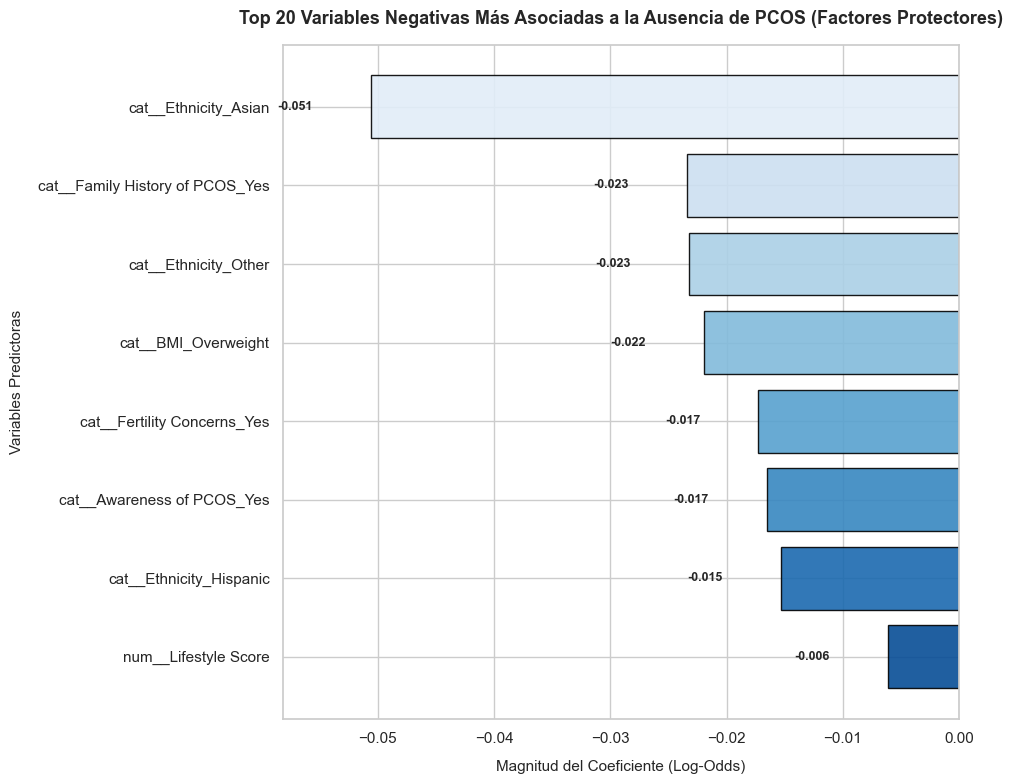

In [63]:
# =================================================== #
#  ## IMPORTANCIA VARIABLES NEGATIVAS (PCOS)     #
# =================================================== #
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aseguramos el renderizado estático en el cuaderno
%matplotlib inline

# 1. EXTRACCIÓN DE NOMBRES DE VARIABLES
feature_names = (
    pipeline_logit.named_steps["preprocessing"]
    .get_feature_names_out()
)

# 2. EXTRACCIÓN DE COEFICIENTES
coeficients = (
    pipeline_logit.named_steps["model"]
    .coef_[0]
)

# Creación del DataFrame de importancia
importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficients
})

# 3. FILTRADO DE COEFICIENTES NEGATIVOS
# Ordenamos de menor a mayor (los más negativos/protectores van primero)
importance_negative = (
    importance_df[importance_df["Coeficiente"] < 0]
    .sort_values(by="Coeficiente", ascending=True)
)

# Tomamos el Top 20 de impacto negativo
top_negative = importance_negative.head(20)

# =================================================== #
#     GRÁFICA HORIZONTAL CON MATPLOTLIB Y SEABORN     #
# =================================================== #
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Para que el impacto más fuerte (el más negativo) quede en la parte superior
top_negative = top_negative.sort_values(by="Coeficiente", ascending=False)

# Creamos la gráfica con una paleta de azules degradados (Blues)
colors = sns.color_palette("Blues_r", len(top_negative))
bars = plt.barh(
    top_negative["Variable"], 
    top_negative["Coeficiente"], 
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Añadimos los valores numéricos al final de cada barra (hacia la izquierda del cero)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 0.005,                     # Un poco a la izquierda del final de la barra negativa
        bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', 
        va='center', 
        ha='right',                        # Alineación a la derecha para que no pise la barra
        fontsize=9, 
        fontweight='bold'
    )

# Títulos y formato formal de los ejes adaptado a PCOS
plt.title("Top 20 Variables Negativas Más Asociadas a la Ausencia de PCOS (Factores Protectores)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Magnitud del Coeficiente (Log-Odds)", fontsize=11, labelpad=10)
plt.ylabel("Variables Predictoras", fontsize=11, labelpad=10)

# Ajustamos el límite izquierdo del eje X para que los textos negativos quepan holgadamente
plt.xlim(min(top_negative["Coeficiente"]) * 1.15, 0)

plt.tight_layout()
plt.show()

TABLA DE TOP 20 VARIABLES GLOBALES
                         Variable  Coeficiente  Importancia
             cat__BMI_Underweight     0.093787     0.093787
 cat__Socioeconomic Status_Middle     0.070165     0.070165
             cat__Ethnicity_Asian    -0.050591     0.050591
           cat__Stress Levels_Low     0.029120     0.029120
  cat__Family History of PCOS_Yes    -0.023442     0.023442
             cat__Ethnicity_Other    -0.023259     0.023259
              cat__BMI_Overweight    -0.021968     0.021968
      cat__Insulin Resistance_Yes     0.019683     0.019683
         cat__Ethnicity_Caucasian     0.019625     0.019625
      cat__Fertility Concerns_Yes    -0.017264     0.017264
       cat__Awareness of PCOS_Yes    -0.016523     0.016523
    cat__Socioeconomic Status_Low     0.015922     0.015922
          cat__Ethnicity_Hispanic    -0.015315     0.015315
        cat__Stress Levels_Medium     0.014348     0.014348
                         num__Age     0.013044     0.013044
     

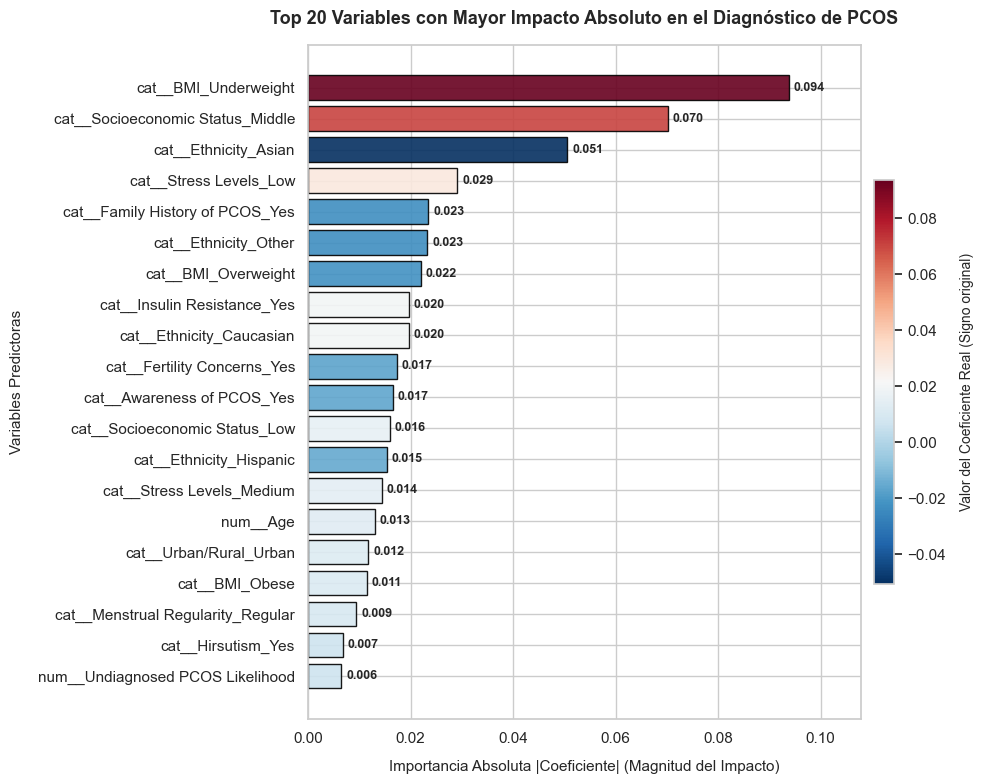

In [64]:
# =================================================== #
#   IMPORTANCIA GLOBAL DE VARIABLES (PCOS)      #
# =================================================== #
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Aseguramos el renderizado estático en el cuaderno
%matplotlib inline

# 1. EXTRACCIÓN DE NOMBRES DE VARIABLES
feature_names = (
    pipeline_logit.named_steps["preprocessing"]
    .get_feature_names_out()
)

# 2. EXTRACCIÓN DE COEFICIENTES
coeficients = (
    pipeline_logit.named_steps["model"]
    .coef_[0]
)

# Creación del DataFrame calculando el valor absoluto de la importancia
importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficients,
    "Importancia": np.abs(coeficients)
})

# Ordenamos de mayor a menor magnitud absoluta
importance_df = importance_df.sort_values(by="Importancia", ascending=False)

# Tomamos el Top 20 global
top_importance = importance_df.head(20)

# Imprimimos la tabla en texto plano como pide el script original
print("="*35)
print("TABLA DE TOP 20 VARIABLES GLOBALES")
print("="*35)
print(top_importance.to_string(index=False))
print("\n")

# =================================================== #
#     GRÁFICA HORIZONTAL CON MATPLOTLIB Y SEABORN     #
# =================================================== #
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Ordenamos de menor a mayor importancia absoluta para que la barra más larga quede arriba
top_importance = top_importance.sort_values(by="Importancia", ascending=True)

# Mapeamos los colores usando una paleta Divergente (Red-Blue) basada en el Coeficiente Real
# Los coeficientes muy positivos tenderán a rojo y los muy negativos a azul
norm = plt.Normalize(top_importance["Coeficiente"].min(), top_importance["Coeficiente"].max())
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
colors = [sm.to_rgba(c) for c in top_importance["Coeficiente"]]

# Dibujamos las barras horizontales
bars = plt.barh(
    top_importance["Variable"], 
    top_importance["Importancia"], 
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Añadimos los valores de magnitud de la importancia sobre el final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max(top_importance["Importancia"]) * 0.01), # Espaciado dinámico a la derecha
        bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='bold'
    )

# Añadimos la barra de color (Colorbar) para que se entienda el gradiente de los coeficientes
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02, shrink=0.6)
cbar.set_label("Valor del Coeficiente Real (Signo original)", fontsize=10, labelpad=10)

# Títulos y nombres de ejes adaptados formalmente a PCOS
plt.title("Top 20 Variables con Mayor Impacto Absoluto en el Diagnóstico de PCOS", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Importancia Absoluta |Coeficiente| (Magnitud del Impacto)", fontsize=11, labelpad=10)
plt.ylabel("Variables Predictoras", fontsize=11, labelpad=10)

# Ajustamos límites de visibilidad para el texto
plt.xlim(0, max(top_importance["Importancia"]) * 1.15)

plt.tight_layout()
plt.show()

## 4.2 ÁRBOL DE CLASIFICACIÓN

### 4.2.1 Entrenamiento

In [65]:
# =================== #
# PREPROCESAMIENTO #
# =================== #

preprocessor_tree = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols) ], 
                                 remainder="passthrough"
                                 )

In [66]:
# ================================== #
# PIPELINE ÁRBOL DE CLASIFICACIÓN   #
# ================================== #
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.tree import DecisionTreeClassifier

pipeline_tree = ImbPipeline([
    (
        "preprocessing", 
        preprocessor_tree
    ),
    (
        "balanceo", 
        SMOTETomek(sampling_strategy=0.5, random_state=123)  # <--- Balancea los datos procesados
    ),
    (
        "model", 
        DecisionTreeClassifier(
            random_state=123,
            class_weight='balanced'  # Le da peso extra a la clase médica minoritaria
        )
    )
])

# Entrenamos el pipeline con tus datos originales de Pandas
pipeline_tree.fit(X_train, y_train)

print("¡Pipeline del Árbol de Clasificación balanceado y entrenado con éxito!")

¡Pipeline del Árbol de Clasificación balanceado y entrenado con éxito!


In [67]:
# ================= #
# ENTRENAMIENTO #
# ================= #

pipeline_tree.fit(
    X_train,
    y_train
)
print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [68]:
# ================ #
# PREDICCIONES #
# ================ #

y_pred = pipeline_tree.predict(X_test)
y_prob = pipeline_tree.predict_proba(X_test)[:,1]

MÉTRICAS DEL MODELO
Accuracy : 0.7991
Precision: 0.1062
Recall   : 0.1233
F1-Score : 0.1141
ROC-AUC  : 0.5008


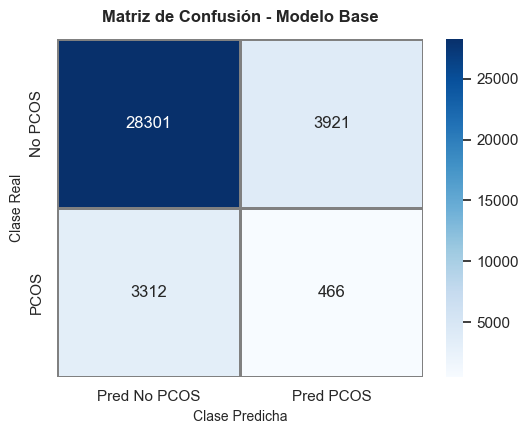



 REPORTE DE CLASIFICACIÓN 
              precision    recall  f1-score   support

     No PCOS       0.90      0.88      0.89     32222
        PCOS       0.11      0.12      0.11      3778

    accuracy                           0.80     36000
   macro avg       0.50      0.50      0.50     36000
weighted avg       0.81      0.80      0.81     36000





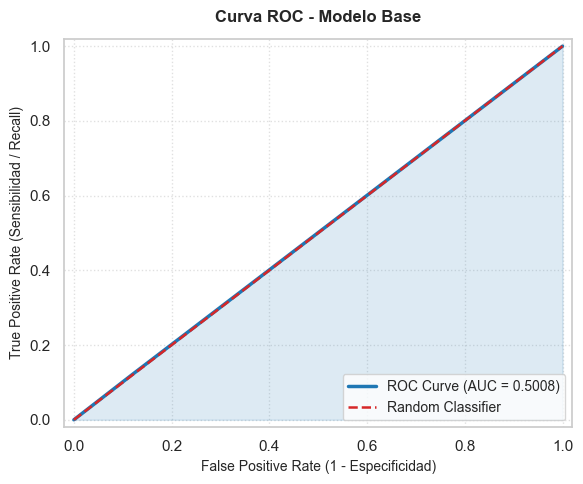

In [69]:
# ============================= #
# MÉTRICAS DE CLASIFICACIÓN #
# ============================= #

# MÉTRICAS
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# RESULTADOS
print("="*19)
print("MÉTRICAS DEL MODELO")
print("="*19)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


# =================================================== #
#  ## EVALUACIÓN DE RENDIMIENTO - MODELO BASE (PCOS)  #
# =================================================== #

# Aseguramos el renderizado estático en el cuaderno
%matplotlib inline

# --- 1. CÁLCULO DEL ROC-AUC REAL DEL MODELO BASE ---
# Recalculamos el AUC exacto para guardarlo en la variable 'auc_base'
auc_base = roc_auc_score(y_test, y_prob)

# =================================================== #
#       1. MATRIZ DE CONFUSIÓN (SEABORN)             #
# =================================================== #
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.set_theme(style="white") # Fondo limpio para la matriz

# Cambiamos "Spam" por tus etiquetas reales médicas de PCOS
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["Pred No PCOS", "Pred PCOS"],
    yticklabels=["No PCOS", "PCOS"],
    linewidths=1, 
    linecolor="gray"
)

plt.title("Matriz de Confusión - Modelo Base", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Clase Real", fontsize=10)
plt.xlabel("Clase Predicha", fontsize=10)
plt.tight_layout()
plt.show()

# =================================================== #
#       2. REPORTE DE CLASIFICACIÓN (TEXTO)          #
# =================================================== #
print("\n")
print("="*26)
print(" REPORTE DE CLASIFICACIÓN ")
print("="*26)
# Corregimos target_names para que coincida con el dominio de PCOS
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No PCOS", "PCOS"]
    )
)
print("\n")

# =================================================== #
#       3. CURVA ROC (MATPLOTLIB)                    #
# =================================================== #
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
sns.set_theme(style="whitegrid") # Cuadrícula para la curva ROC

# Dibujamos la curva ROC y sombreamos el área inferior (simulando go.Scatter/px.area)
plt.plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"ROC Curve (AUC = {auc_base:.4f})")
plt.fill_between(fpr, tpr, alpha=0.15, color="#1f77b4")

# Línea diagonal segmentada del clasificador aleatorio
plt.plot([0, 1], [0, 1], color="#d62728", linestyle="--", lw=1.8, label="Random Classifier")

# Límites y nombres formales de los ejes axiales
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)", fontsize=10)
plt.ylabel("True Positive Rate (Sensibilidad / Recall)", fontsize=10)
plt.title("Curva ROC - Modelo Base", fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### 4.2.2 Validación Cruzada 

In [70]:
# ======================== #
# K-FOLD ESTRATIFICADO #
# ======================== #

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

In [71]:
# ====================== #
#  MÉTRICAS A EVALUAR #
# ====================== #

metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [73]:
# ==================== #
# CROSS VALIDATION #
# ==================== #

cv_results = cross_validate(
    estimator=pipeline_tree,
    X=X,
    y=y,




    cv=cv,
    scoring=metrics,
    return_train_score=False,
    n_jobs=-1,
)

In [74]:
# ======================= #
# RESULTADOS PROMEDIO #
# ======================= #

results_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Promedio": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],

    "Desv. Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

results_df[["Promedio", "Desv. Std"]] = (
    results_df[["Promedio", "Desv. Std"]]
    .round(4)
)

In [75]:
# ====================== #
# MOSTRAR RESULTADOS #
# ====================== #

print("\n")
print("="*29)
print("RESULTADOS VALIDACIÓN CRUZADA")
print("="*29)
print(results_df)



RESULTADOS VALIDACIÓN CRUZADA
     Métrica  Promedio  Desv. Std
0   Accuracy    0.8008     0.0025
1  Precision    0.1072     0.0058
2     Recall    0.1225     0.0079
3   F1-Score    0.1143     0.0066
4    ROC-AUC    0.5014     0.0037


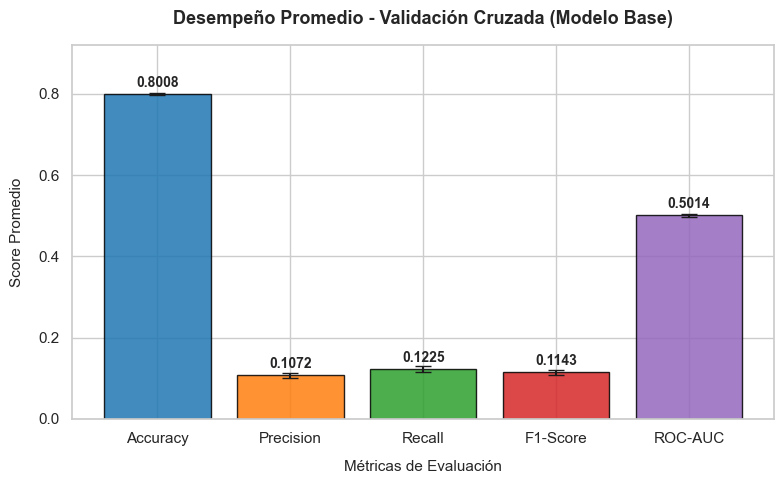

In [76]:
# =================================================== #
#   ## 18. GRÁFICA DE MÉTRICAS - BASE (Matplotlib)   #
# =================================================== #
import matplotlib.pyplot as plt
import seaborn as sns

# Aseguramos el renderizado estático dentro de VS Code
%matplotlib inline

# Configuración estética de la figura
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Creamos la gráfica de barras usando las columnas reales de tu variable 'results_df'
bars = plt.bar(
    results_df["Métrica"], 
    results_df["Promedio"], 
    yerr=results_df["Desv. Std"], 
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],
    capsize=6,          # Ancho de las líneas de error estándar (sigma)
    alpha=0.85, 
    edgecolor="black"
)

# Insertamos las etiquetas de texto con los promedios reales sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        height + 0.01, 
        f'{height:.4f}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

# Títulos y nombres de ejes axiales adaptados formalmente
plt.title("Desempeño Promedio - Validación Cruzada (Modelo Base)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Métricas de Evaluación", fontsize=11, labelpad=10)
plt.ylabel("Score Promedio", fontsize=11, labelpad=10)

# Ajuste dinámico del límite superior del eje Y para evitar cortes de texto
plt.ylim(0, max(results_df["Promedio"]) + 0.12)

# Despliegue estático en la interfaz del notebook
plt.tight_layout()
plt.show()

### 4.2.3 Ajuste de Hiperparámetros

In [ ]:
# ========================================== #
#    19. OPTIMIZACIÓN DE HIPERPARÁMETROS     #
# RANDOMIZED SEARCH - ÁRBOL DE CLASIFICACIÓN #
# ========================================== #

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from scipy.stats import uniform

# ====================== #
# 20. VALIDACIÓN CRUZADA #
# ====================== #

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

In [ ]:
# ===================== #
# 21. RANDOMIZED SEARCH #
# ===================== #

param_dist = {

    "model__criterion": [
        "gini",
        "entropy"
    ],

    "model__max_depth": [
        None,
        3,
        5,
        7,
        10,
        15,
        20
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "model__max_features": [
        None,
        "sqrt",
        "log2"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]

}

In [ ]:
# ==================== #
# 22. RANDOM SEARCH CV #
# ==================== #

random_search = RandomizedSearchCV(
    estimator=pipeline_tree,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=10,
    verbose=1,
    random_state=123,
    n_jobs=-1
)

# =============================== #
# 23. ENTRENAMIENTO RANDOM SEARCH #
# =============================== #

random_search.fit(
    X_train,
    y_train
)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [None, 3, ...], 'model__max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valida

In [ ]:
# ================ #
# 24. MEJOR MODELO #
# ================ #

best_model = random_search.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [ ]:
# =========================== #
# 25. MEJORES HIPERPARÁMETROS #
# =========================== #

print("")
print("="*23)
print("MEJORES HIPERPARÁMETROS")
print("="*23)

for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")


MEJORES HIPERPARÁMETROS
model__min_samples_split: 20
model__min_samples_leaf: 1
model__max_features: None
model__max_depth: 20
model__criterion: entropy
model__class_weight: None


In [ ]:
# ============================= #
# 26. PREDICCIONES MEJOR MODELO #
# ============================= #

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

In [ ]:
# ============================================================================== #
# 27. MÉTRICAS MEJOR MODELO
# ============================================================================== #

print("")
print("="*21)
print("MÉTRICAS MEJOR MODELO")
print("="*21)
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")


MÉTRICAS MEJOR MODELO
Accuracy : 0.8865
Precision: 0.1241
Recall   : 0.0135
F1-Score : 0.0243
ROC-AUC  : 0.5005


### 4.2.4 Importancia de Variables

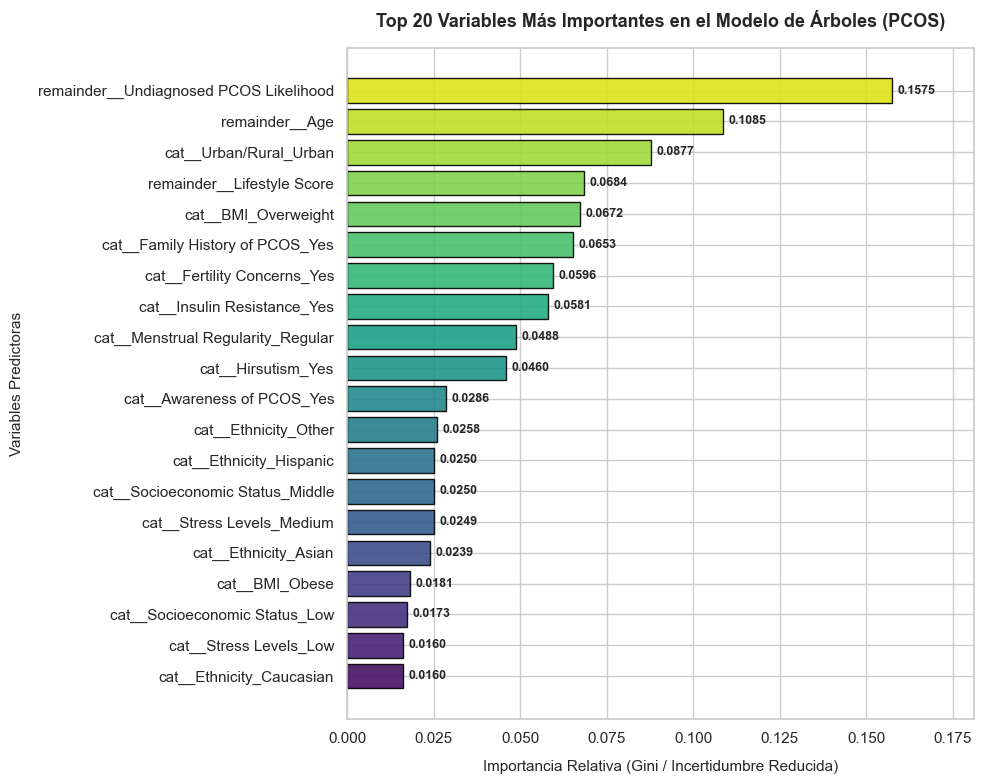

In [ ]:
# =================================================== #
#  IMPORTANCIA DE VARIABLES EN ÁRBOLES (PCOS)  #
# =================================================== #
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aseguramos el renderizado estático dentro del cuaderno
%matplotlib inline

# 1. EXTRACCIÓN DE NOMBRES DE VARIABLES
feature_names = (
    pipeline_tree.named_steps["preprocessing"]
    .get_feature_names_out()
)

# 2. EXTRACCIÓN DE IMPORTANCIAS DE ÁRBOLES (Gini Importance / Gain)
importances = (
    pipeline_tree.named_steps["model"]
    .feature_importances_
)

# Creación del DataFrame de importancia
importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
})

# Ordenamos de mayor a menor impacto global
importance_df = importance_df.sort_values(by="Importancia", ascending=False)

# Tomamos el Top 20 para la visualización
top_importance = importance_df.head(20)

# =================================================== #
#     GRÁFICA HORIZONTAL CON MATPLOTLIB Y SEABORN     #
# =================================================== #
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Ordenamos al revés para que la variable más importante quede en la parte superior
top_importance = top_importance.sort_values(by="Importancia", ascending=True)

# Creamos la gráfica con una paleta degradada de tonos morados/azules (Viridis)
colors = sns.color_palette("viridis", len(top_importance))
bars = plt.barh(
    top_importance["Variable"], 
    top_importance["Importancia"], 
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Añadimos los valores numéricos con 4 decimales al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max(top_importance["Importancia"]) * 0.01), # Pequeño espacio dinámico a la derecha
        bar.get_y() + bar.get_height()/2, 
        f'{width:.4f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='bold'
    )

# Títulos y formato formal adaptado al laboratorio de PCOS
plt.title("Top 20 Variables Más Importantes en el Modelo de Árboles (PCOS)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Importancia Relativa (Gini / Incertidumbre Reducida)", fontsize=11, labelpad=10)
plt.ylabel("Variables Predictoras", fontsize=11, labelpad=10)

# Ajustamos el límite del eje X para evitar cortes en las etiquetas de texto
plt.xlim(0, max(top_importance["Importancia"]) * 1.15)

plt.tight_layout()
plt.show()

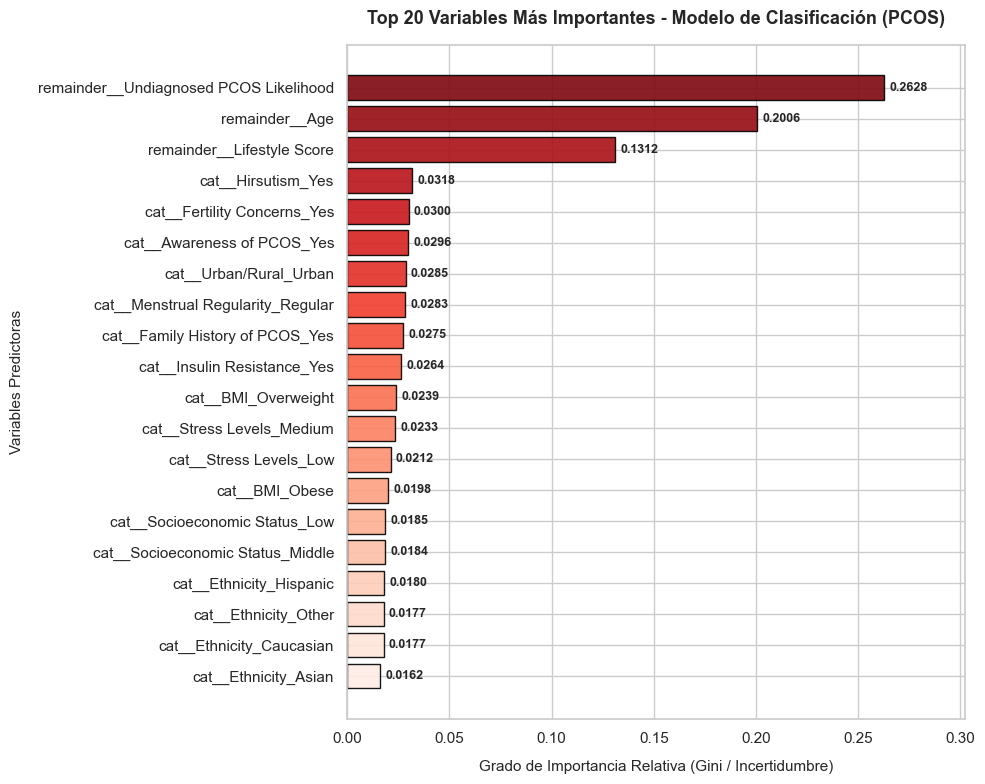

In [ ]:
# =================================================== #
#   TOP 20 VARIABLES IMPORTANTES (Matplotlib)   #
# =================================================== #
import matplotlib.pyplot as plt
import seaborn as sns

# Aseguramos el renderizado estático dentro del cuaderno
%matplotlib inline

# Tomamos el Top 20 para la visualización (ya ordenado en la celda anterior)
top_importance = importance_df.head(20)

# =================================================== #
#     GRÁFICA HORIZONTAL CON MATPLOTLIB Y SEABORN     #
# =================================================== #
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Volvemos a ordenar de menor a mayor para que la barra más larga quede arriba al graficar
top_importance = top_importance.sort_values(by="Importancia", ascending=True)

# Creamos la gráfica usando una paleta degradada de rojos (Reds)
colors = sns.color_palette("Reds", len(top_importance))
bars = plt.barh(
    top_importance["Variable"], 
    top_importance["Importancia"], 
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Añadimos las etiquetas numéricas con 4 decimales al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max(top_importance["Importancia"]) * 0.01), # Margen a la derecha
        bar.get_y() + bar.get_height()/2, 
        f'{width:.4f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='bold'
    )

# Títulos y nombres de ejes axiales adaptados formalmente a PCOS
plt.title("Top 20 Variables Más Importantes - Modelo de Clasificación (PCOS)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Grado de Importancia Relativa (Gini / Incertidumbre)", fontsize=11, labelpad=10)
plt.ylabel("Variables Predictoras", fontsize=11, labelpad=10)

# Ajustamos límites de visibilidad para que no se corten los números flotantes
plt.xlim(0, max(top_importance["Importancia"]) * 1.15)

plt.tight_layout()
plt.show()

### 4.2.5 Entrenamiento final


In [ ]:

# =========================================== #
# ENTRENAMIENTO FINAL CON TODOS LOS DATOS #
# =========================================== #

final_model = Pipeline([
    ("preprocessing", preprocessor_tree),
    (
        "model",
        DecisionTreeClassifier(
            criterion=random_search.best_params_[
                "model__criterion"
            ],
            max_depth=random_search.best_params_[
                "model__max_depth"
            ],
            min_samples_split=random_search.best_params_[
                "model__min_samples_split"
            ],
            min_samples_leaf=random_search.best_params_[
                "model__min_samples_leaf"
            ],
            max_features=random_search.best_params_[
                "model__max_features"
            ],
            class_weight=random_search.best_params_[
                "model__class_weight"
            ],
            random_state=123
        )
    )
])



In [ ]:
# ======================= #
#  ENTRENAMIENTO FINAL #
# ======================= #

final_model.fit(X,y)

## 4.3 RANDOM FOREST CLASSIFIER

### 4.3.1 Entrenamiento

In [105]:
# =================== #
# 7. PREPROCESAMIENTO #
# =================== #

preprocessor_rf = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols) ], 
                                 remainder="passthrough"
                                 )

In [106]:
# =========== #
# 9. PIPELINE #
# =========== #

pipeline_rf = Pipeline([
    ("preprocessing", preprocessor_rf),
    (
        "model",
        RandomForestClassifier(
            random_state=123,
            oob_score=True,
            class_weight='balanced'
        )
    )
])

In [107]:
# ================= #
# 10. ENTRENAMIENTO #
# ================= #

pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given stri

In [108]:
# ================ #
# 11. PREDICCIONES #
# ================ #

y_pred = pipeline_rf.predict(X_test)

y_prob = pipeline_rf.predict_proba(X_test)[:,1]

In [109]:
# ============ #
#  MÉTRICAS #
# ============ #

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# ============== #
#  RESULTADOS #
# ============== #

print("="*22)
print("MÉTRICAS RANDOM FOREST")
print("="*22)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

MÉTRICAS RANDOM FOREST
Accuracy : 0.8946
Precision: 0.0526
Recall   : 0.0003
F1-Score : 0.0005
ROC-AUC  : 0.5075


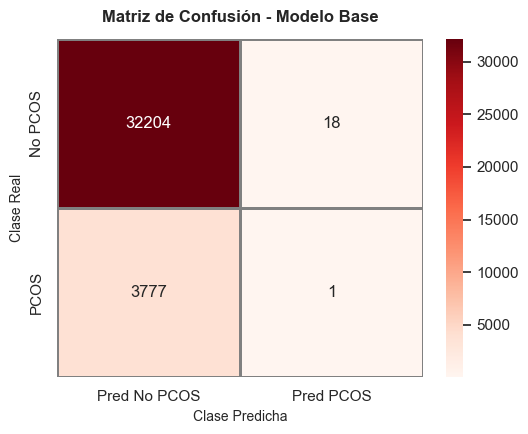

In [110]:


# Cálculo de la matriz con tus variables reales del modelo base
cm = confusion_matrix(y_test, y_pred)

# Configuramos la figura
plt.figure(figsize=(5.5, 4.5))
sns.set_theme(style="white") # Fondo limpio para que resalten los valores

# Graficamos la matriz adaptando las etiquetas al dominio médico de PCOS
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Reds", 
    xticklabels=["Pred No PCOS", "Pred PCOS"],
    yticklabels=["No PCOS", "PCOS"],
    linewidths=1, 
    linecolor="gray"
)

# Títulos y nombres de ejes axiales
plt.title("Matriz de Confusión - Modelo Base", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Clase Real", fontsize=10)
plt.xlabel("Clase Predicha", fontsize=10)

plt.tight_layout()
plt.show()

In [111]:
# ========================= #
# 15. CLASSIFICATION REPORT #
# ========================= #

print("")
print("="*22)
print("CLASSIFICATION REPORT")
print("="*22)
print(
    classification_report(
        y_test,
        y_pred
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      1.00      0.94     32222
           1       0.05      0.00      0.00      3778

    accuracy                           0.89     36000
   macro avg       0.47      0.50      0.47     36000
weighted avg       0.81      0.89      0.85     36000



### 4.3.2 Validación Cruzada 

In [112]:
# ====================== #
# 17. VALIDACIÓN CRUZADA #
# ====================== #

cv_results = cross_validate(
    pipeline_rf,
    X_train,
    y_train,
    cv=5,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=False
)


# ================================= #
# 18. RESULTADOS VALIDACIÓN CRUZADA #
# ================================= #

print("")
print("="*18)
print("VALIDACIÓN CRUZADA")
print("="*18)
print(f"Accuracy CV : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision CV: {cv_results['test_precision'].mean():.4f}")
print(f"Recall CV   : {cv_results['test_recall'].mean():.4f}")
print(f"F1-Score CV : {cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC CV  : {cv_results['test_roc_auc'].mean():.4f}")


VALIDACIÓN CRUZADA
Accuracy CV : 0.8947
Precision CV: 0.0200
Recall CV   : 0.0001
F1-Score CV : 0.0002
ROC-AUC CV  : 0.5026


### 4.3.3 Ajuste de Hiperparámetros

In [113]:
# ================= #
# 19. RANDOM SEARCH #
# ================= #

param_dist = {
    "model__oob_score": [
        True
    ],
    
    "model__criterion": [
        "gini",
        "entropy"
    ],
    
    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        None,
        5,
        10,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        None
    ],

    "model__bootstrap": [
        True,
        False
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}



In [116]:
# ======================== #
# 20. RANDOMIZED SEARCH CV #
# ======================== #

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=123,
    n_jobs=-1
)

In [119]:
# =============================== #
# 21. ENTRENAMIENTO RANDOM SEARCH #
# =============================== #

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

### 4.3.4 Importancia de Variables

## 4.4 XGBOOST CLASSIFIER

### 4.4.1 Entrenamiento

Executing: Ajuste y Evaluación Simple (Antes de CV)...

Métrica              | Train      | Test      
--------------------------------------------------
Accuracy             | 0.5863     | 0.5397
Precision (Clase 1)  | 0.1586     | 0.1059
Recall (Sensitivity) | 0.6831     | 0.4547
F1-Score             | 0.2574     | 0.1718
ROC-AUC              | 0.6847     | 0.4976

REPORTE DETALLADO POR CLASE (TEST):
              precision    recall  f1-score   support

           0       0.90      0.55      0.68     32222
           1       0.11      0.45      0.17      3778

    accuracy                           0.54     36000
   macro avg       0.50      0.50      0.43     36000
weighted avg       0.81      0.54      0.63     36000



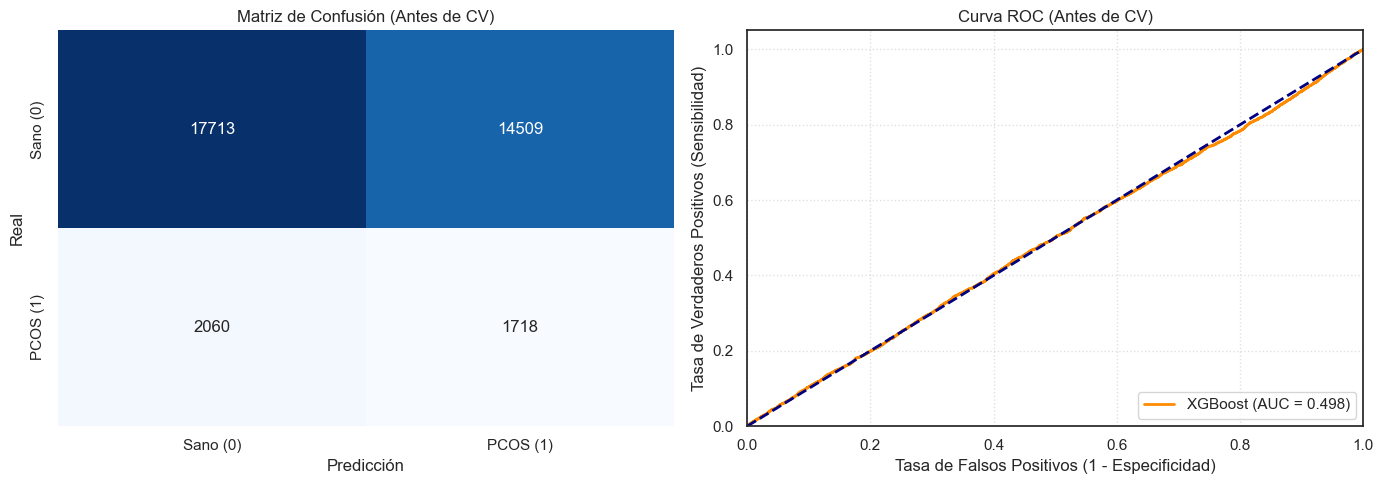

In [124]:
# =========================================================================== #
#   ## ENTRENAMIENTO, MÉTRICAS Y GRÁFICAS: ANTES Y DURANTE CV (XGBOOST - PCOS)  #
# =========================================================================== #

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- 1. CONFIGURACIÓN DEL PIPELINE DE XGBOOST ---

# Extraemos tu preprocesador real (desde el pipeline de regresión logística)
preprocessor = pipeline_logit.named_steps["preprocessing"]

# Cálculo del factor de balanceo nativo para XGBoost
factor_balanceo = np.sum(y_train == 0) / np.sum(y_train == 1)

# DEFINICIÓN DEL PIPELINE UNIFICADO
pipeline_xgb = Pipeline(
    steps=[
        ("preprocessing", preprocessor),  # Aquí se aplican tus transformaciones
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                scale_pos_weight=factor_balanceo,
                random_state=42,
                eval_metric="logloss",
            ),
        ),
    ]
)


# =========================================================================== #
#   [FASE 1] MÉTRICAS Y GRÁFICAS ANTES DE LA VALIDACIÓN CRUZADA (EVAL. SIMPLE) #
# =========================================================================== #
print("Executing: Ajuste y Evaluación Simple (Antes de CV)...")

# Ajustamos el pipeline COMPLETO en el set de entrenamiento directo
# Esto ejecuta el preprocesamiento y luego entrena el XGBClassifier internamente
pipeline_xgb.fit(X_train, y_train)

# Predicciones utilizando el pipeline (aplica transformaciones automáticamente a X_test)
y_pred_antes = pipeline_xgb.predict(X_test)
y_prob_antes = pipeline_xgb.predict_proba(X_test)[:, 1]

# Predicciones sobre Train para evaluar sobreajuste (overfitting)
y_pred_train = pipeline_xgb.predict(X_train)
y_prob_train = pipeline_xgb.predict_proba(X_train)[:, 1]


# --- REPORTE COMPACTO DE MÉTRICAS MÁS IMPORTANTES ---
print("\n" + "=" * 50)
print(f"{'Métrica':<20} | {'Train':<10} | {'Test':<10}")
print("-" * 50)
print(
    f"{'Accuracy':<20} | {accuracy_score(y_train, y_pred_train):.4f}     | {accuracy_score(y_test, y_pred_antes):.4f}"
)
print(
    f"{'Precision (Clase 1)':<20} | {precision_score(y_train, y_pred_train):.4f}     | {precision_score(y_test, y_pred_antes):.4f}"
)
print(
    f"{'Recall (Sensitivity)':<20} | {recall_score(y_train, y_pred_train):.4f}     | {recall_score(y_test, y_pred_antes):.4f}"
)
print(
    f"{'F1-Score':<20} | {f1_score(y_train, y_pred_train):.4f}     | {f1_score(y_test, y_pred_antes):.4f}"
)
print(
    f"{'ROC-AUC':<20} | {roc_auc_score(y_train, y_prob_train):.4f}     | {roc_auc_score(y_test, y_prob_antes):.4f}"
)
print("=" * 50)

# --- REPORTE DETALLADO DE CLASIFICACIÓN ---
print("\nREPORTE DETALLADO POR CLASE (TEST):")
print(classification_report(y_test, y_pred_antes))


# --- 2. GENERACIÓN DE GRÁFICAS (MATRIZ Y ROC) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica A: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_antes)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0],
    cbar=False,
    xticklabels=["Sano (0)", "PCOS (1)"],
    yticklabels=["Sano (0)", "PCOS (1)"],
)
ax[0].set_title("Matriz de Confusión (Antes de CV)")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Real")

# Gráfica B: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_antes)
auc_val = roc_auc_score(y_test, y_prob_antes)

ax[1].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"XGBoost (AUC = {auc_val:.3f})"
)
ax[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax[1].set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax[1].set_title("Curva ROC (Antes de CV)")
ax[1].legend(loc="lower right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

### 4.4.2 Validación Cruzada 

### 4.4.3 Ajuste de Hiperparámetros

### 4.4.4 Importancia de Variables

# 5. Comparación de Modelos

# 6. Evaluación Final